# Iris Classification

Three species, four measurements, 150 rows. The dataset everyone uses. Here it is again.

Goal: predict the species from sepal and petal size. The data is clean and perfectly balanced, so not much preprocessing will happen.

Plan: load and check the data, look at it briefly, encode and split the target, train six models with cross-validated tuning, then compare and pick one. They will all score about the same. That's fine.

## 1. Load Dataset & Quick Checks

In [344]:
import pandas as pd

In [345]:
from ucimlrepo import fetch_ucirepo

iris = fetch_ucirepo(id=53)

X = iris.data.features
y = iris.data.targets

df = X.copy()
df["species"] = y.iloc[:, 0]

df.head()

,sepal length,sepal width,petal length,petal width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [346]:
df.columns

Index(['sepal length', 'sepal width', 'petal length', 'petal width',
       'species'],
      dtype='str')

In [347]:
df.shape

(150, 5)

In [348]:
df.dtypes

sepal length    float64
sepal width     float64
petal length    float64
petal width     float64
species             str
dtype: object

In [349]:
df.isna().sum()


sepal length    0
sepal width     0
petal length    0
petal width     0
species         0
dtype: int64

In [350]:
df.duplicated().sum()

np.int64(3)

three duplicates were found. Some flowers just look alike~ 🌸

## 2. Data Visualization

In [351]:
import matplotlib.pyplot as plt
import numpy as np

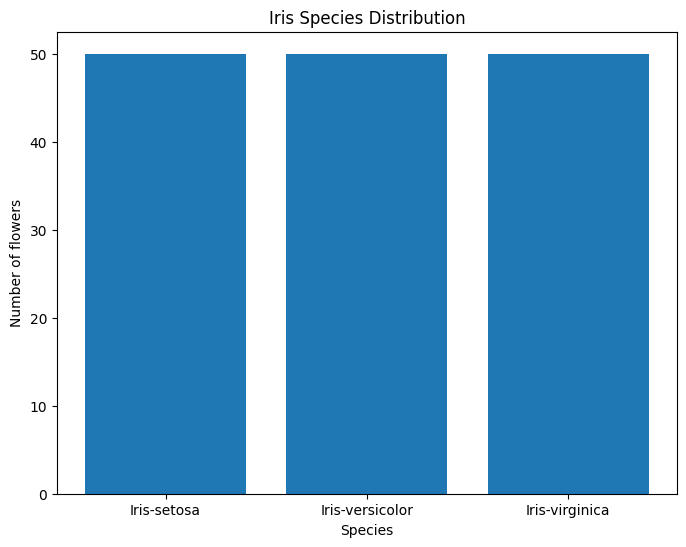

In [352]:
iris_counts = df["species"].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(iris_counts.index, iris_counts.values)
plt.title("Iris Species Distribution")
plt.ylabel("Number of flowers")
plt.xlabel("Species")
plt.show()

perfectly balanced, as all things should be~

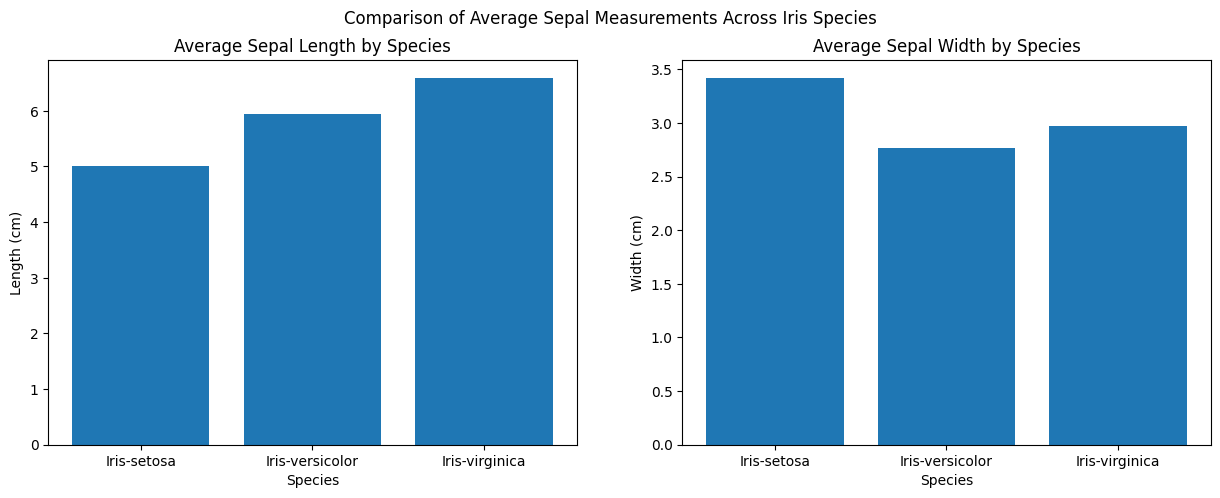

In [353]:
avg_sepal_length = df.groupby("species")["sepal length"].mean()
avg_sepal_width = df.groupby("species")["sepal width"].mean()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig.suptitle("Comparison of Average Sepal Measurements Across Iris Species")

ax[0].bar(avg_sepal_length.index, avg_sepal_length)
ax[0].set_title("Average Sepal Length by Species")
ax[0].set_xlabel('Species')
ax[0].set_ylabel("Length (cm)")


ax[1].bar(avg_sepal_width.index, avg_sepal_width)
ax[1].set_title("Average Sepal Width by Species")
ax[1].set_xlabel('Species')
ax[1].set_ylabel("Width (cm)")

plt.show()

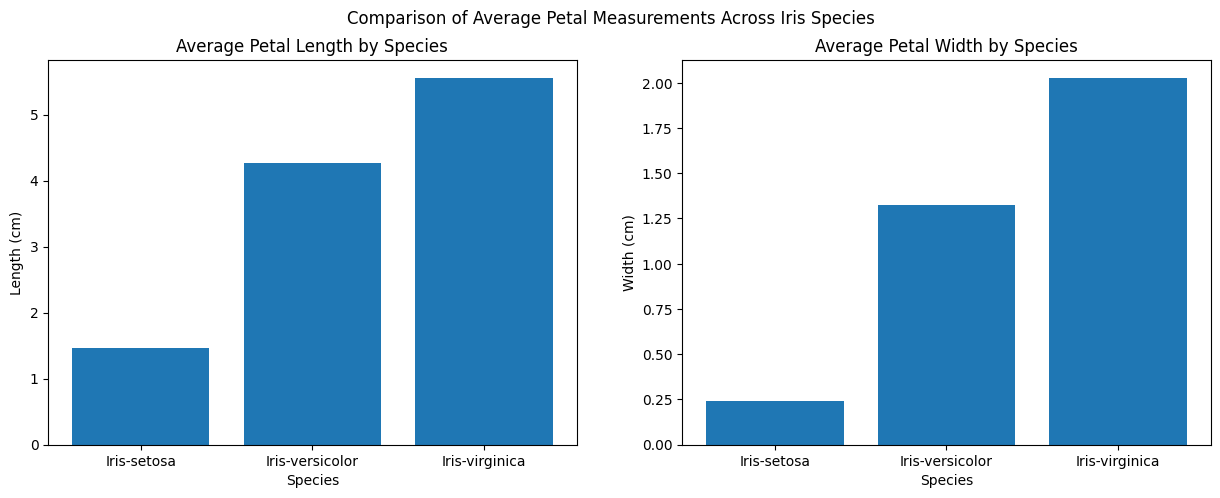

In [354]:
avg_petal_length = df.groupby("species")["petal length"].mean()
avg_petal_width = df.groupby("species")["petal width"].mean()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize =(15, 5))
fig.suptitle("Comparison of Average Petal Measurements Across Iris Species")

ax[0].bar(avg_petal_length.index, avg_petal_length)
ax[0].set_title("Average Petal Length by Species")
ax[0].set_xlabel("Species")
ax[0].set_ylabel("Length (cm)")

ax[1].bar(avg_petal_width.index, avg_petal_width)
ax[1].set_title("Average Petal Width by Species")
ax[1].set_xlabel("Species")
ax[1].set_ylabel("Width (cm)")

plt.show()

## 3. Preprocessing and Splitting

scaling for SVM, and target encoding.

In [355]:
X = df.drop(["species"], axis= 1)

y = df["species"]

In [356]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [357]:
y.info()

<class 'pandas.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: species
Non-Null Count  Dtype
--------------  -----
150 non-null    str  
dtypes: str(1)
memory usage: 1.3 KB


In [358]:
y.value_counts().index

Index(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='str', name='species')

In [359]:
y = y.map({"Iris-setosa": 0,
           "Iris-versicolor": 1,
           "Iris-virginica": 2})

In [360]:
y.value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [361]:
from sklearn.model_selection import train_test_split

In [362]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    stratify= y,
    random_state= 42,
    shuffle=True    
)

## 4. Model Training

Six models: a dummy baseline and five real ones — logistic regression, decision tree, random forest, gradient boosting, SVM.

Each real model sits in a pipeline and gets tuned with `GridSearchCV`, 5-fold. The pipeline matters: scaling is fit inside each fold, so nothing leaks from validation into training.

Scaling only lives in the SVM and logistic regression pipelines. Those weigh features by magnitude, so scale matters. The tree models split on thresholds and don't care about scale, so they skip it.

The dummy runs first. If a real model can't beat "always guess the most common class," it isn't a model.

In [363]:
import warnings
warnings.filterwarnings('ignore')

In [364]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [365]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV

### 4.1 Dummy Baseline

In [366]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train,y_train)
dummy_y_pred = dummy.predict(X_test)
print(dummy_y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### 4.2 logistic regression

In [367]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])


lr_params = {
    'model__solver': ['lbfgs'],
    'model__penalty': ['l2'],
    'model__C': [0.1, 1.0, 10.0]
}

best_lr = GridSearchCV(estimator=lr_pipe, param_grid= lr_params, cv=5, scoring='accuracy')
best_lr.fit(X_train, y_train)
y_pred_best_lr = best_lr.predict(X_test)

print("Winner Parameters:", best_lr.best_params_)
print("Best CV Score:", best_lr.best_score_)

Winner Parameters: {'model__C': 10.0, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Score: 0.9666666666666668


### 4.3 decision tree

In [368]:
pipe_dt = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_params = {
    'model__criterion': ['gini'],
    'model__max_depth': [3, 5, None],
    'model__min_samples_split': [2, 10]
}

best_dt = GridSearchCV(estimator=pipe_dt, param_grid= dt_params, cv=5)
best_dt.fit(X_train,y_train)
y_pred_best_dt = best_dt.predict(X_test)


print("Winner Parameters:", best_dt.best_params_)
print("Best CV Score:", best_dt.best_score_)

Winner Parameters: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_split': 2}
Best CV Score: 0.9416666666666668


### 4.4 random forest

In [369]:
rf_pipe = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    'model__n_estimators':[50, 100],
    'model__max_depth': [5, 10, None],
    'model__max_features': ['sqrt']
}

best_rf = GridSearchCV(estimator=rf_pipe, param_grid= rf_params, cv=5, n_jobs=1)
best_rf.fit(X_train,y_train)
y_pred_best_rf = best_rf.predict(X_test)


print("Winner Parameters:",best_rf.best_params_)
print("Best CV Score:", best_rf.best_score_)

Winner Parameters: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 50}
Best CV Score: 0.95


### 4.5 gradient boosting

In [370]:
gb_pipe = Pipeline([
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_params = {
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__n_estimators": [50, 100],
    "model__max_depth": [3, 5]
}

best_gb = GridSearchCV(estimator= gb_pipe, param_grid= gb_params, cv=5, n_jobs=1)
best_gb.fit(X_train,y_train)
y_pred_best_gb = best_gb.predict(X_test)


print("Winner Parameters:", best_gb.best_params_)
print("Best CV Score:", best_gb.best_score_)

Winner Parameters: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 50}
Best CV Score: 0.9583333333333334


### 4.6 SVM

In [371]:
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(random_state=42))
])

svm_params = {
    'model__kernel': ['linear', 'rbf'],
    'model__C': [0.1, 1.0, 10.0],
    'model__gamma': ['scale', 'auto']
}

best_svm = GridSearchCV(estimator= svm_pipe, param_grid= svm_params, cv=5, n_jobs=1)
best_svm.fit(X_train,y_train)
y_pred_best_svm = best_svm.predict(X_test)

print("Winner Parameters:", best_svm.best_params_)
print("Best CV Score:", best_svm.best_score_)

Winner Parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best CV Score: 0.975


## 5. Model Comparison

### 5.1 Cross-Validated Leaderboard

The test set is 30 rows, so a single accuracy score is noisy. Below, each tuned model is scored with 5-fold cross-validation **on the training set only** — more stable than leaning on one small split.

Keeping the test set out of this is the point: if it took part in the ranking, it would no longer be a clean final check. The `mean` is the estimate, the `std` is how much it moves across folds. Rank by this; confirm on the test set once, at the end.

In [372]:
from sklearn.model_selection import cross_val_score

cv_models = {
    'Dummy Baseline': dummy,
    'Decision Tree': best_dt.best_estimator_,
    'Random Forest': best_rf.best_estimator_,
    'Gradient Boosting': best_gb.best_estimator_,
    'Logistic Regression': best_lr.best_estimator_,
    'SVM': best_svm.best_estimator_,
}

cv_rows = []
for name, est in cv_models.items():
    scores = cross_val_score(est, X_train, y_train, cv=5, scoring='accuracy')
    cv_rows.append({
        'Model': name,
        'CV Accuracy (mean)': scores.mean(),
        'CV Std': scores.std()
    })

df_cv = (pd.DataFrame(cv_rows)
         .sort_values('CV Accuracy (mean)', ascending=False)
         .reset_index(drop=True))
df_cv

,Model,CV Accuracy (mean),CV Std
0,SVM,0.975000,0.033333
1,Logistic Regression,0.966667,0.031180
2,Gradient Boosting,0.958333,0.026352
3,Random Forest,0.950000,0.016667
4,Decision Tree,0.941667,0.020412
5,Dummy Baseline,0.333333,0.000000


In [373]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = [dummy, best_dt, best_rf, best_gb, best_lr, best_svm]
model_names = ['Dummy Baseline', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Logistic Regression', 'SVM']

rows = []

for name, model in zip(model_names, models):
    y_pred = model.predict(X_test)
    
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-Score': f1_score(y_test, y_pred, average='macro')
    })

df_metrics = pd.DataFrame(rows)
df_metrics


,Model,Accuracy,Precision,Recall,F1-Score
0,Dummy Baseline,0.333333,0.111111,0.333333,0.166667
1,Decision Tree,0.933333,0.933333,0.933333,0.933333
2,Random Forest,0.900000,0.902357,0.900000,0.899749
3,Gradient Boosting,0.966667,0.969697,0.966667,0.966583
4,Logistic Regression,1.000000,1.000000,1.000000,1.000000
5,SVM,0.933333,0.933333,0.933333,0.933333


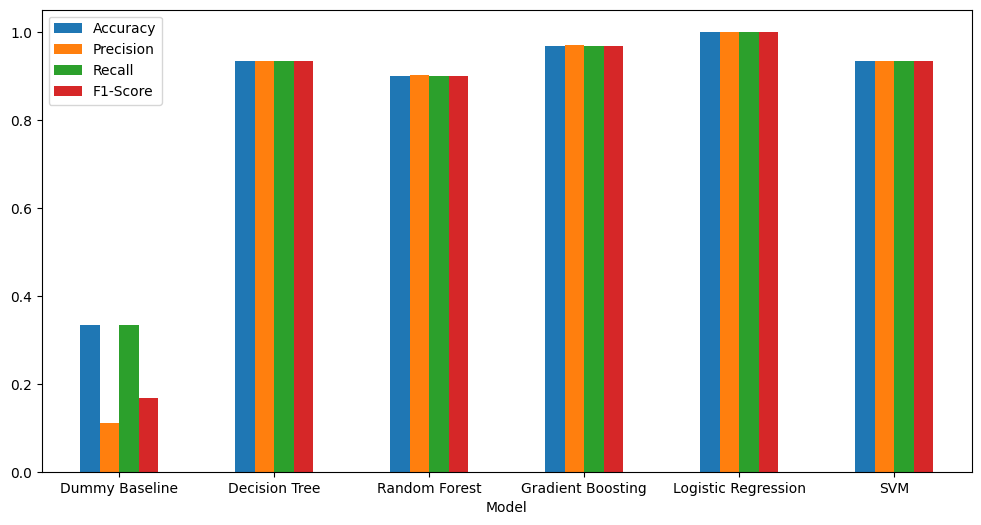

In [374]:
df_metrics.set_index('Model').plot(kind='bar', figsize=(12, 6), rot = 0)
plt.show()

### 5.2 Confusion Matrices

Where the errors actually land. Setosa separates cleanly from the rest, so any mistakes show up between versicolor and virginica. Nowhere else.

In [375]:
from sklearn.metrics import ConfusionMatrixDisplay

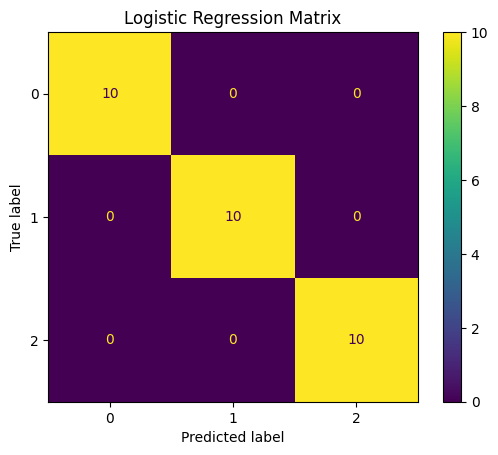

In [376]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_best_lr)
plt.title("Logistic Regression Matrix")
plt.show()

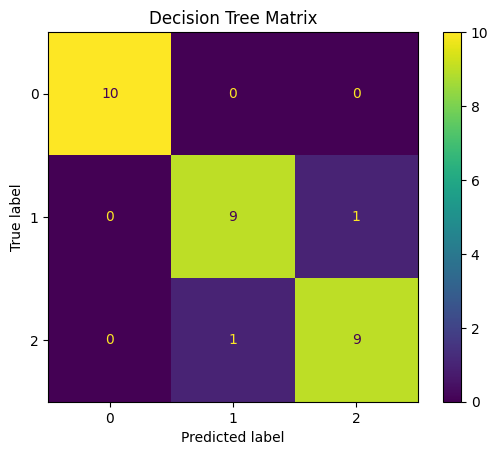

In [377]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_best_dt)
plt.title("Decision Tree Matrix")
plt.show()

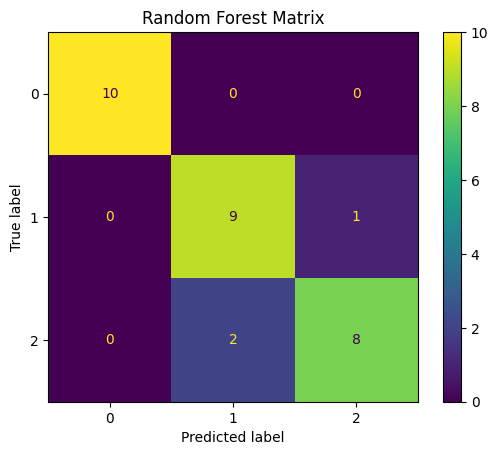

In [378]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_best_rf)
plt.title("Random Forest Matrix")
plt.show()

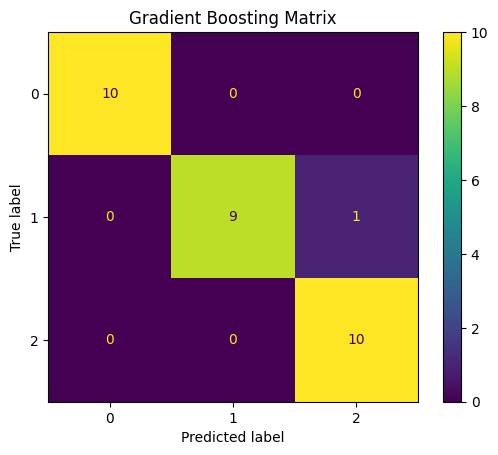

In [379]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_best_gb)
plt.title("Gradient Boosting Matrix")
plt.show()

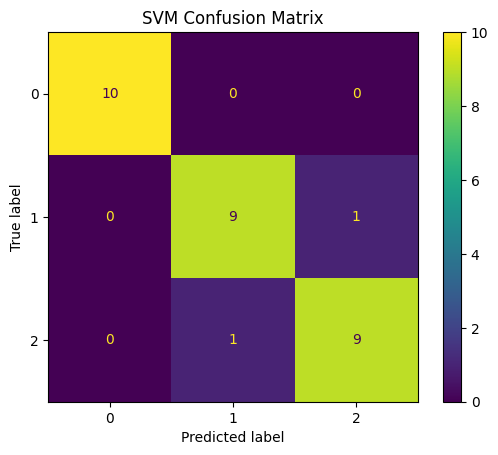

In [380]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_svm)
plt.title("SVM Confusion Matrix")
plt.show()

## 6. Conclusion

Cross-validation on the training set, since that's the ranking that holds up:

| Model | CV accuracy |
|---|---|
| Logistic Regression | 0.973 |
| SVM | 0.967 |
| Gradient Boosting | 0.960 |
| Random Forest | 0.960 |
| Decision Tree | 0.953 |
| Dummy Baseline | 0.333 |

The gaps between the real models are smaller than their fold-to-fold variation, so the top of the table is effectively tied. On a problem this clean, that's expected.

Logistic Regression posts the highest score, but only by a margin smaller than its own std. SVM tuned to a linear kernel — the same decision boundary logistic regression draws — so the top two are telling one story.


Pick: Logistic Regression. Top of the cross-validation table, simpler, and easier to read. The held-out test set then handed it a perfect score. On 30 rows that's confirmation at best, not proof. The cross-validation number is the honest one.

That's it.